In [1]:
# Run this in a new cell
%pip install torch torchvision pillow imageio scikit-learn tqdm

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.1/113.8 MB 1.7 MB/s eta 0:01:09
   ---------------------------------------- 0.1/113.8 MB 1.7 MB/s eta 0:01:07
   ---------------------------------------- 0.2/113.8 MB 1.9 MB/s eta 0:01:02
   ---------------------------------------- 0.2/113.8 MB 1.6 MB/s eta 0:01:12
   ---------------------------------------- 0.3/113.8 MB 1.6 MB/s eta 0:01:10
   ---------------------------------------- 0.3/113.8 MB 1.4 MB/s eta 0:01:24
   ---------------------------------------- 0.4/113.8 MB 1.4 MB/s eta 0:01:20
   ---------------------------------------- 0.5/113.8 MB 1.6 MB/s eta 0:01:13
   ---------------------------------------- 0.5/113.8 MB 1.6 MB/s eta 0:01:11
   ---------------------------------------- 0.6/113.8 MB 1.7 MB/s eta 0:01:08
   ---------------------------------------- 0.7/113.8 MB 1.7 MB/s eta 0:01:07
   -------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pandas as pd
from PIL import Image
import imageio
import numpy as np
from pathlib import Path

class GIFEmotionDataset(Dataset):
    """Dataset for loading GIFs and their emotion labels"""
    
    def __init__(self, csv_file, num_frames=8, transform=None):
        """
        Args:
            csv_file: Path to train/val/test CSV
            num_frames: Number of frames to extract from each GIF
            transform: Image transformations
        """
        self.data = pd.read_csv(csv_file)
        self.num_frames = num_frames
        self.transform = transform
        
        # Create emotion to index mapping
        self.emotions = sorted(self.data['primary_emotion'].unique())
        self.emotion2idx = {emotion: idx for idx, emotion in enumerate(self.emotions)}
        self.idx2emotion = {idx: emotion for emotion, idx in self.emotion2idx.items()}
        
        print(f"Loaded {len(self.data)} samples")
        print(f"Emotions ({len(self.emotions)}): {self.emotions}")
    
    def __len__(self):
        return len(self.data)
    
    def extract_frames(self, gif_path, num_frames=8):
        """Extract evenly spaced frames from GIF"""
        try:
            # Read GIF
            gif = imageio.mimread(gif_path)
            total_frames = len(gif)
            
            if total_frames == 0:
                raise ValueError(f"Empty GIF: {gif_path}")
            
            # Select evenly spaced frames
            if total_frames <= num_frames:
                # If GIF has fewer frames, repeat frames
                indices = list(range(total_frames))
                while len(indices) < num_frames:
                    indices.extend(range(total_frames))
                indices = indices[:num_frames]
            else:
                # Sample evenly spaced frames
                indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
            
            # Extract and convert frames to PIL Images
            frames = []
            for idx in indices:
                frame = gif[idx]
                # Convert to RGB if needed
                if len(frame.shape) == 2:  # Grayscale
                    frame = np.stack([frame] * 3, axis=-1)
                elif frame.shape[2] == 4:  # RGBA
                    frame = frame[:, :, :3]
                
                # Convert to PIL Image
                pil_frame = Image.fromarray(frame.astype('uint8'))
                frames.append(pil_frame)
            
            return frames
            
        except Exception as e:
            print(f"Error loading {gif_path}: {e}")
            # Return blank frames as fallback
            blank = Image.new('RGB', (224, 224), color=(128, 128, 128))
            return [blank] * num_frames
    
    def __getitem__(self, idx):
        """Get a single sample"""
        row = self.data.iloc[idx]
        
        gif_path = row['gif_path']
        emotion = row['primary_emotion']
        label = self.emotion2idx[emotion]
        
        # Extract frames
        frames = self.extract_frames(gif_path, self.num_frames)
        
        # Apply transformations
        if self.transform:
            frames = [self.transform(frame) for frame in frames]
        
        # Stack frames: (num_frames, C, H, W)
        frames_tensor = torch.stack(frames)
        
        return frames_tensor, label

# Test the dataset
print("Testing dataset loader...")
test_dataset = GIFEmotionDataset('train_split.csv', num_frames=8)
print(f"\nEmotion mapping: {test_dataset.emotion2idx}")

Testing dataset loader...
Loaded 4146 samples
Emotions (14): ['amusement', 'anger', 'contempt', 'contentment', 'disgust', 'embarrassment', 'excitement', 'fear', 'happiness', 'pleasure', 'pride', 'sadness', 'satisfaction', 'surprise']

Emotion mapping: {'amusement': 0, 'anger': 1, 'contempt': 2, 'contentment': 3, 'disgust': 4, 'embarrassment': 5, 'excitement': 6, 'fear': 7, 'happiness': 8, 'pleasure': 9, 'pride': 10, 'sadness': 11, 'satisfaction': 12, 'surprise': 13}


In [2]:
from torchvision import transforms

# Image transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),  # Data augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                       std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

print(" Transformations defined")

 Transformations defined


In [3]:
# Use only 1 frame (middle frame) for quick testing
train_dataset = GIFEmotionDataset('train_split.csv', num_frames=1, transform=train_transform)
val_dataset = GIFEmotionDataset('val_split.csv', num_frames=1, transform=val_transform)
test_dataset = GIFEmotionDataset('test_split.csv', num_frames=1, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)  # num_workers=0 for debugging

print(f" DataLoader created:")
print(f"  Train batches: {len(train_loader)}")

# Test loading a batch
print("\nTesting batch loading...")
frames_batch, labels_batch = next(iter(train_loader))
print(f"  Frames shape: {frames_batch.shape}")  # Should be (batch_size, num_frames, 3, 224, 224)
print(f"  Labels shape: {labels_batch.shape}")  # Should be (batch_size,)
print(f"  Sample labels: {labels_batch[:5]}")

Loaded 4146 samples
Emotions (14): ['amusement', 'anger', 'contempt', 'contentment', 'disgust', 'embarrassment', 'excitement', 'fear', 'happiness', 'pleasure', 'pride', 'sadness', 'satisfaction', 'surprise']
Loaded 889 samples
Emotions (14): ['amusement', 'anger', 'contempt', 'contentment', 'disgust', 'embarrassment', 'excitement', 'fear', 'happiness', 'pleasure', 'pride', 'sadness', 'satisfaction', 'surprise']
Loaded 889 samples
Emotions (14): ['amusement', 'anger', 'contempt', 'contentment', 'disgust', 'embarrassment', 'excitement', 'fear', 'happiness', 'pleasure', 'pride', 'sadness', 'satisfaction', 'surprise']
 DataLoader created:
  Train batches: 260

Testing batch loading...
  Frames shape: torch.Size([16, 1, 3, 224, 224])
  Labels shape: torch.Size([16])
  Sample labels: tensor([8, 8, 5, 1, 0])


In [1]:
import imageio
import numpy as np
from PIL import Image
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import os

def preprocess_gif_to_frames(gif_path, output_dir, num_frames=8):
    """Extract frames from GIF and save as individual images"""
    try:
        # Read GIF
        gif = imageio.mimread(gif_path)
        total_frames = len(gif)
        
        if total_frames == 0:
            return None
        
        # Select evenly spaced frames
        if total_frames <= num_frames:
            indices = list(range(total_frames))
            while len(indices) < num_frames:
                indices.extend(range(total_frames))
            indices = indices[:num_frames]
        else:
            indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
        
        # Create output directory for this GIF
        gif_id = Path(gif_path).stem
        gif_output_dir = Path(output_dir) / gif_id
        gif_output_dir.mkdir(parents=True, exist_ok=True)
        
        # Save each frame
        frame_paths = []
        for i, idx in enumerate(indices):
            frame = gif[idx]
            
            # Convert to RGB
            if len(frame.shape) == 2:
                frame = np.stack([frame] * 3, axis=-1)
            elif frame.shape[2] == 4:
                frame = frame[:, :, :3]
            
            # Save frame
            frame_path = gif_output_dir / f"frame_{i:02d}.jpg"
            Image.fromarray(frame.astype('uint8')).save(frame_path, quality=95)
            frame_paths.append(str(frame_path))
        
        return frame_paths
        
    except Exception as e:
        print(f"Error processing {gif_path}: {e}")
        return None

# Pre-process all GIFs
def preprocess_all_gifs(csv_file, output_base_dir, num_frames=8):
    """Pre-process all GIFs in a dataset split"""
    df = pd.read_csv(csv_file)
    
    split_name = Path(csv_file).stem.replace('_split', '')
    output_dir = Path(output_base_dir) / split_name
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\nProcessing {split_name} set ({len(df)} GIFs)...")
    
    processed_data = []
    failed = 0
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):
        gif_path = row['gif_path']
        frame_paths = preprocess_gif_to_frames(gif_path, output_dir, num_frames)
        
        if frame_paths:
            row_data = row.to_dict()
            row_data['frame_paths'] = '|'.join(frame_paths)  # Store as pipe-separated
            row_data['num_extracted_frames'] = len(frame_paths)
            processed_data.append(row_data)
        else:
            failed += 1
    
    # Save processed CSV
    processed_df = pd.DataFrame(processed_data)
    output_csv = output_base_dir / f"{split_name}_processed.csv"
    processed_df.to_csv(output_csv, index=False)
    
    print(f" {split_name}: {len(processed_df)} GIFs processed, {failed} failed")
    print(f"   Saved to: {output_csv}")
    
    return output_csv

# Run preprocessing
OUTPUT_DIR = Path("processed_frames")
OUTPUT_DIR.mkdir(exist_ok=True)

print("="*60)
print("PRE-PROCESSING GIFS TO FRAMES")
print("="*60)
print(f"This will take 10-30 minutes but only needs to run ONCE!")
print(f"Output directory: {OUTPUT_DIR}")

# Process all splits
preprocess_all_gifs('train_split.csv', OUTPUT_DIR, num_frames=8)
preprocess_all_gifs('val_split.csv', OUTPUT_DIR, num_frames=8)
preprocess_all_gifs('test_split.csv', OUTPUT_DIR, num_frames=8)

print("\n" + "="*60)
print(" PRE-PROCESSING COMPLETE!")
print("="*60)

PRE-PROCESSING GIFS TO FRAMES
This will take 10-30 minutes but only needs to run ONCE!
Output directory: processed_frames

Processing train set (4146 GIFs)...


Processing train:  24%|██▍       | 1013/4146 [00:53<10:01,  5.21it/s]

Error processing D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1\gifgif-images\vxjRjlfhYwacg.gif: imageio.mimread() has read over 256000000B of image data.
Stopped to avoid memory problems. Use imageio.get_reader(), increase threshold, or memtest=False


Processing train:  33%|███▎      | 1352/4146 [01:13<02:27, 18.92it/s]

Error processing D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1\gifgif-images\R1CJ00kQSO0fe.gif: image file is truncated (155 bytes not processed)


...

Error processing D:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\Data\gifgif-images-v1\gifgif-images\12jxWorxHQ321O.gif: imageio.mimread() has read over 256000000B of image data.
Stopped to avoid memory problems. Use imageio.get_reader(), increase threshold, or memtest=False


Processing train: 100%|██████████| 4146/4146 [04:01<00:00, 17.18it/s]


 train: 4143 GIFs processed, 3 failed
   Saved to: processed_frames\train_processed.csv

Processing val set (889 GIFs)...


Processing val:  76%|███████▌  | 674/889 [00:36<00:11, 18.87it/s]

: 

In [1]:
import imageio.v2 as imageio  # Use v2 API for better memory handling
import numpy as np
from PIL import Image
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import os
import gc  # Garbage collector

def preprocess_gif_to_frames_safe(gif_path, output_dir, num_frames=8, max_frames_to_read=100):
    """Extract frames from GIF with memory safety"""
    try:
        # Use get_reader for better memory control
        reader = imageio.get_reader(gif_path)
        
        # Get total frames (safely)
        try:
            total_frames = len(reader)
        except:
            # If can't get length, sample first max_frames_to_read
            total_frames = max_frames_to_read
        
        # Cap at reasonable number to avoid memory issues
        total_frames = min(total_frames, max_frames_to_read)
        
        if total_frames == 0:
            reader.close()
            return None
        
        # Calculate which frames to extract
        if total_frames <= num_frames:
            indices = list(range(total_frames))
            while len(indices) < num_frames:
                indices.extend(range(total_frames))
            indices = indices[:num_frames]
        else:
            indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
        
        # Create output directory
        gif_id = Path(gif_path).stem
        gif_output_dir = Path(output_dir) / gif_id
        gif_output_dir.mkdir(parents=True, exist_ok=True)
        
        # Extract and save frames one by one (memory efficient)
        frame_paths = []
        for i, frame_idx in enumerate(indices):
            try:
                frame = reader.get_data(frame_idx)
                
                # Convert to RGB
                if len(frame.shape) == 2:
                    frame = np.stack([frame] * 3, axis=-1)
                elif frame.shape[2] == 4:
                    frame = frame[:, :, :3]
                elif frame.shape[2] > 4:
                    frame = frame[:, :, :3]
                
                # Save frame
                frame_path = gif_output_dir / f"frame_{i:02d}.jpg"
                Image.fromarray(frame.astype('uint8')).save(frame_path, quality=85)  # Lower quality to save space
                frame_paths.append(str(frame_path))
                
            except Exception as e:
                print(f"  Warning: Could not extract frame {frame_idx} from {gif_id}: {e}")
                continue
        
        reader.close()
        
        # Only return if we got at least some frames
        if len(frame_paths) >= num_frames // 2:
            return frame_paths
        else:
            return None
        
    except Exception as e:
        print(f"Error processing {Path(gif_path).name}: {str(e)[:100]}")
        return None
    finally:
        # Force garbage collection
        gc.collect()

def preprocess_all_gifs_safe(csv_file, output_base_dir, num_frames=8):
    """Pre-process all GIFs with memory safety"""
    df = pd.read_csv(csv_file)
    
    split_name = Path(csv_file).stem.replace('_split', '')
    output_dir = Path(output_base_dir) / split_name
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\nProcessing {split_name} set ({len(df)} GIFs)...")
    
    processed_data = []
    failed = 0
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):
        gif_path = row['gif_path']
        
        # Process GIF
        frame_paths = preprocess_gif_to_frames_safe(gif_path, output_dir, num_frames)
        
        if frame_paths:
            row_data = row.to_dict()
            row_data['frame_paths'] = '|'.join(frame_paths)
            row_data['num_extracted_frames'] = len(frame_paths)
            processed_data.append(row_data)
        else:
            failed += 1
        
        # Periodic garbage collection every 100 GIFs
        if idx % 100 == 0:
            gc.collect()
    
    # Save processed CSV
    processed_df = pd.DataFrame(processed_data)
    output_csv = output_base_dir / f"{split_name}_processed.csv"
    processed_df.to_csv(output_csv, index=False)
    
    print(f" {split_name}: {len(processed_df)} GIFs processed, {failed} failed ({failed/len(df)*100:.1f}%)")
    print(f"   Saved to: {output_csv}")
    
    return output_csv

# Run preprocessing with memory safety
OUTPUT_DIR = Path("processed_frames")
OUTPUT_DIR.mkdir(exist_ok=True)

print("="*60)
print("PRE-PROCESSING GIFS TO FRAMES (MEMORY-SAFE)")
print("="*60)
print(f"Output directory: {OUTPUT_DIR}")
print(f"This will take 15-30 minutes but only needs to run ONCE!\n")

# Process all splits
try:
    train_csv = preprocess_all_gifs_safe('train_split.csv', OUTPUT_DIR, num_frames=8)
    val_csv = preprocess_all_gifs_safe('val_split.csv', OUTPUT_DIR, num_frames=8)
    test_csv = preprocess_all_gifs_safe('test_split.csv', OUTPUT_DIR, num_frames=8)
    
    print("\n" + "="*60)
    print(" PRE-PROCESSING COMPLETE!")
    print("="*60)
    print(f"Processed CSVs:")
    print(f"  - {train_csv}")
    print(f"  - {val_csv}")
    print(f"  - {test_csv}")
    
except Exception as e:
    print(f"\n Error during processing: {e}")
    import traceback
    traceback.print_exc()

PRE-PROCESSING GIFS TO FRAMES (MEMORY-SAFE)
Output directory: processed_frames
This will take 15-30 minutes but only needs to run ONCE!


Processing train set (4146 GIFs)...


Processing train:   0%|          | 0/4146 [00:00<?, ?it/s]

Processing train:   0%|          | 1/4146 [00:00<13:51,  4.99it/s]

Processing train:   0%|          | 2/4146 [00:00<15:19,  4.51it/s]

Processing train:   0%|          | 3/4146 [00:00<14:01,  4.92it/s]

...

Processing train:   4%|▍         | 182/4146 [00:53<13:17,  4.97it/s]

Processing train:   4%|▍         | 183/4146 [00:54<14:06,  4.68it/s]

Processing train:   4%|▍         | 184/4146 [00:54<14:40,  4.50it/s]

Processing train:   4%|▍         | 184/4146 [00:55<19:46,  3.34it/s]


KeyboardInterrupt: 

In [2]:
from PIL import Image
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import numpy as np

def extract_middle_frame(gif_path):
    """Extract the middle frame from a GIF using PIL"""
    try:
        with Image.open(gif_path) as gif:
            # Count total frames
            n_frames = 0
            try:
                while True:
                    gif.seek(n_frames)
                    n_frames += 1
            except EOFError:
                pass
            
            if n_frames == 0:
                return None
            
            # Get middle frame
            middle_idx = n_frames // 2
            gif.seek(middle_idx)
            
            # Convert to RGB
            frame = gif.convert('RGB')
            
            return frame
            
    except Exception as e:
        return None

def preprocess_single_frame(csv_file, output_base_dir):
    """Process all GIFs - extract middle frame only"""
    df = pd.read_csv(csv_file)
    
    split_name = Path(csv_file).stem.replace('_split', '')
    output_dir = Path(output_base_dir) / split_name
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\n{'='*60}")
    print(f"Processing {split_name} set: {len(df)} GIFs")
    print(f"{'='*60}")
    
    processed_data = []
    failed = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name}"):
        gif_path = row['gif_path']
        gif_id = Path(gif_path).stem
        
        # Extract middle frame
        frame = extract_middle_frame(gif_path)
        
        if frame is not None:
            # Save frame
            frame_path = output_dir / f"{gif_id}.jpg"
            frame.save(frame_path, quality=90)
            
            # Add to processed data
            row_data = row.to_dict()
            row_data['frame_path'] = str(frame_path)
            processed_data.append(row_data)
        else:
            failed.append(gif_id)
    
    # Save processed CSV
    processed_df = pd.DataFrame(processed_data)
    output_csv = output_base_dir / f"{split_name}_processed.csv"
    processed_df.to_csv(output_csv, index=False)
    
    # Summary
    success_rate = (len(processed_df) / len(df)) * 100
    print(f"\n Results:")
    print(f"   Successfully processed: {len(processed_df)}/{len(df)} ({success_rate:.1f}%)")
    print(f"   Failed: {len(failed)}")
    print(f"   Saved to: {output_csv}")
    
    if len(failed) > 0 and len(failed) <= 10:
        print(f"\n️  Failed GIFs: {failed}")
    elif len(failed) > 10:
        print(f"\n️  Failed GIFs (first 10): {failed[:10]}")
    
    return output_csv, processed_df

# Run preprocessing
OUTPUT_DIR = Path("processed_frames_single")
OUTPUT_DIR.mkdir(exist_ok=True)

print("="*60)
print("EXTRACTING MIDDLE FRAME FROM EACH GIF")
print("="*60)
print("This will be fast, clean, and consistent!")
print()

# Process all splits
train_csv, train_df = preprocess_single_frame('train_split.csv', OUTPUT_DIR)
val_csv, val_df = preprocess_single_frame('val_split.csv', OUTPUT_DIR)
test_csv, test_df = preprocess_single_frame('test_split.csv', OUTPUT_DIR)

print("\n" + "="*60)
print(" PREPROCESSING COMPLETE!")
print("="*60)
print(f"\nDataset Summary:")
print(f"  Train: {len(train_df)} GIFs")
print(f"  Val:   {len(val_df)} GIFs")
print(f"  Test:  {len(test_df)} GIFs")
print(f"  Total: {len(train_df) + len(val_df) + len(test_df)} GIFs")
print(f"\nAll frames saved to: {OUTPUT_DIR}")

EXTRACTING MIDDLE FRAME FROM EACH GIF
This will be fast, clean, and consistent!


Processing train set: 4146 GIFs


train: 100%|██████████| 4146/4146 [02:31<00:00, 27.33it/s]



 Results:
   Successfully processed: 4145/4146 (100.0%)
   Failed: 1
   Saved to: processed_frames_single\train_processed.csv

️  Failed GIFs: ['R1CJ00kQSO0fe']

Processing val set: 889 GIFs


val: 100%|██████████| 889/889 [00:31<00:00, 27.82it/s]



 Results:
   Successfully processed: 889/889 (100.0%)
   Failed: 0
   Saved to: processed_frames_single\val_processed.csv

Processing test set: 889 GIFs


test: 100%|██████████| 889/889 [00:39<00:00, 22.60it/s]


 Results:
   Successfully processed: 889/889 (100.0%)
   Failed: 0
   Saved to: processed_frames_single\test_processed.csv

 PREPROCESSING COMPLETE!

Dataset Summary:
  Train: 4145 GIFs
  Val:   889 GIFs
  Test:  889 GIFs
  Total: 5923 GIFs

All frames saved to: processed_frames_single


In [1]:
# Test if data loading works
print("Testing data loading...")

import time
start = time.time()

# Try loading one batch
try:
    batch = next(iter(train_loader))
    images, labels = batch
    elapsed = time.time() - start
    
    print(f" Batch loaded successfully in {elapsed:.2f} seconds")
    print(f"   Images shape: {images.shape}")
    print(f"   Labels shape: {labels.shape}")
    print(f"   Sample labels: {labels[:5]}")
    
except Exception as e:
    print(f" Error loading batch: {e}")
    import traceback
    traceback.print_exc()

Testing data loading...
 Error loading batch: name 'train_loader' is not defined


Traceback (most recent call last):
  File "C:\Users\akind\AppData\Local\Temp\ipykernel_17744\4261216125.py", line 9, in <module>
    batch = next(iter(train_loader))
                      ^^^^^^^^^^^^
NameError: name 'train_loader' is not defined


In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

class PreprocessedGIFDataset(Dataset):
    """Dataset for preprocessed single-frame GIFs"""
    
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        
        # Create emotion mapping
        self.emotions = sorted(self.data['primary_emotion'].unique())
        self.emotion2idx = {emotion: idx for idx, emotion in enumerate(self.emotions)}
        self.idx2emotion = {idx: emotion for emotion, idx in self.emotion2idx.items()}
        
        print(f" Loaded {len(self.data)} samples with {len(self.emotions)} emotions")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Load preprocessed frame
        frame_path = row['frame_path']
        frame = Image.open(frame_path).convert('RGB')
        
        # Get label
        emotion = row['primary_emotion']
        label = self.emotion2idx[emotion]
        
        # Apply transform
        if self.transform:
            frame = self.transform(frame)
        
        return frame, label

# Image transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = PreprocessedGIFDataset('processed_frames_single/train_processed.csv', transform=train_transform)
val_dataset = PreprocessedGIFDataset('processed_frames_single/val_processed.csv', transform=val_transform)
test_dataset = PreprocessedGIFDataset('processed_frames_single/test_processed.csv', transform=val_transform)

# Create dataloaders - CRITICAL: num_workers=0 for Windows/Jupyter!
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n{'='*60}")
print(f" DataLoaders Ready!")
print(f"{'='*60}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")
print(f"  Batch size: {BATCH_SIZE}")

print(f"\n Emotion mapping:")
for emotion, idx in sorted(train_dataset.emotion2idx.items(), key=lambda x: x[1]):
    print(f"  {idx:2d}: {emotion}")

# Quick test - should complete in <5 seconds
print(f"\n Testing batch loading...")
import time
start = time.time()

batch_images, batch_labels = next(iter(train_loader))
elapsed = time.time() - start

print(f" Batch loaded in {elapsed:.2f} seconds")
print(f"   Images shape: {batch_images.shape}")  # Should be (32, 3, 224, 224)
print(f"   Labels shape: {batch_labels.shape}")  # Should be (32,)
print(f"   Sample emotions: {[train_dataset.idx2emotion[l.item()] for l in batch_labels[:5]]}")

print(f"\n{'='*60}")
print(f" Everything working! Ready to build model.")
print(f"{'='*60}")

 Loaded 4145 samples with 14 emotions
 Loaded 889 samples with 14 emotions
 Loaded 889 samples with 14 emotions

 DataLoaders Ready!
  Train batches: 130
  Val batches: 28
  Test batches: 28
  Batch size: 32

 Emotion mapping:
   0: amusement
   1: anger
   2: contempt
   3: contentment
   4: disgust
   5: embarrassment
   6: excitement
   7: fear
   8: happiness
   9: pleasure
  10: pride
  11: sadness
  12: satisfaction
  13: surprise

 Testing batch loading...
 Batch loaded in 0.53 seconds
   Images shape: torch.Size([32, 3, 224, 224])
   Labels shape: torch.Size([32])
   Sample emotions: ['happiness', 'satisfaction', 'surprise', 'fear', 'embarrassment']

 Everything working! Ready to build model.


In [2]:
import torch
import torch.nn as nn
from torchvision import models

class GIFEmotionClassifier(nn.Module):
    """ResNet-based emotion classifier"""
    
    def __init__(self, num_classes=14, pretrained=True):
        super(GIFEmotionClassifier, self).__init__()
        
        # Load pretrained ResNet50
        self.resnet = models.resnet50(pretrained=pretrained)
        
        # Replace final layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.resnet(x)

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GIFEmotionClassifier(num_classes=14, pretrained=True)
model = model.to(device)

print(f"{'='*60}")
print(f" Model Created!")
print(f"{'='*60}")
print(f"  Device: {device}")
print(f"  Architecture: ResNet50")
print(f"  Number of classes: 14")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Test forward pass
test_input = torch.randn(2, 3, 224, 224).to(device)
test_output = model(test_input)
print(f"\n Forward pass test:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print(f"  Expected: (2, 14) " if test_output.shape == (2, 14) else "   Shape mismatch!")

d:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\gifgif-env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\IIT\Year 4\FYP\Datasets\GIFGIF_lucas\gifgif-env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\akind/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:41<00:00, 2.49MB/s]


 Model Created!
  Device: cpu
  Architecture: ResNet50
  Number of classes: 14
  Total parameters: 24,564,302
  Trainable parameters: 24,564,302

 Forward pass test:
  Input shape: torch.Size([2, 3, 224, 224])
  Output shape: torch.Size([2, 14])
  Expected: (2, 14) 


In [4]:
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights for imbalanced dataset
emotion_labels = train_dataset.data['primary_emotion'].map(train_dataset.emotion2idx).values
class_weights = compute_class_weight(
    'balanced',
    classes=np.arange(14),
    y=emotion_labels
)
class_weights = torch.FloatTensor(class_weights).to(device)

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Learning rate scheduler (removed verbose parameter)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

print(f"{'='*60}")
print(f" Training Setup Complete!")
print(f"{'='*60}")
print(f"  Loss: CrossEntropyLoss with class weights")
print(f"  Optimizer: Adam (lr=0.0001)")
print(f"  Scheduler: ReduceLROnPlateau")

print(f"\n Class weights (top 5 rarest emotions):")
weight_emotion_pairs = [(train_dataset.idx2emotion[i], class_weights[i].item()) 
                        for i in range(14)]
for emotion, weight in sorted(weight_emotion_pairs, key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {emotion:15s}: {weight:.3f}")

 Training Setup Complete!
  Loss: CrossEntropyLoss with class weights
  Optimizer: Adam (lr=0.0001)
  Scheduler: ReduceLROnPlateau

 Class weights (top 5 rarest emotions):
  contentment    : 2.741
  embarrassment  : 2.716
  contempt       : 2.407
  pride          : 2.209
  amusement      : 2.161


In [5]:
from tqdm import tqdm

def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{running_loss/len(loader):.4f}',
            'acc': f'{100*correct/total:.2f}%'
        })
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print(" Training functions defined")

 Training functions defined


In [6]:
# Training parameters
NUM_EPOCHS = 15
BEST_ACC = 0.0

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print(f"{'='*60}")
print(f" STARTING TRAINING")
print(f"{'='*60}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Device: {device}")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(val_dataset)}")
print(f"{'='*60}\n")

for epoch in range(NUM_EPOCHS):
    print(f"\n Epoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_acc)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print epoch summary
    print(f"\n Epoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    
    # Save best model
    if val_acc > BEST_ACC:
        BEST_ACC = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"   New best model saved! (Val Acc: {val_acc:.2f}%)")

print(f"\n{'='*60}")
print(f" TRAINING COMPLETE!")
print(f"{'='*60}")
print(f"  Best Validation Accuracy: {BEST_ACC:.2f}%")
print(f"  Model saved as: best_model.pth")

 STARTING TRAINING
  Epochs: 15
  Device: cpu
  Training samples: 4145
  Validation samples: 889


 Epoch 1/15
------------------------------------------------------------


Validation: 100%|██████████| 28/28 [01:36<00:00,  3.44s/it]



 Epoch 1 Summary:
  Train Loss: 2.6383 | Train Acc: 9.38%
  Val Loss:   2.5986 | Val Acc:   12.26%
   New best model saved! (Val Acc: 12.26%)

 Epoch 2/15
------------------------------------------------------------


Validation: 100%|██████████| 28/28 [01:18<00:00,  2.79s/it]



 Epoch 2 Summary:
  Train Loss: 2.5422 | Train Acc: 12.91%
  Val Loss:   2.5979 | Val Acc:   10.69%

 Epoch 3/15
------------------------------------------------------------


...


 Epoch 13 Summary:
  Train Loss: 0.4549 | Train Acc: 77.66%
  Val Loss:   4.5459 | Val Acc:   16.31%

 Epoch 14/15
------------------------------------------------------------


Validation: 100%|██████████| 28/28 [02:27<00:00,  5.28s/it]



 Epoch 14 Summary:
  Train Loss: 0.3833 | Train Acc: 80.99%
  Val Loss:   4.5470 | Val Acc:   19.24%
   New best model saved! (Val Acc: 19.24%)

 Epoch 15/15
------------------------------------------------------------


Validation: 100%|██████████| 28/28 [02:33<00:00,  5.47s/it]


 Epoch 15 Summary:
  Train Loss: 0.3060 | Train Acc: 84.37%
  Val Loss:   4.7376 | Val Acc:   21.15%
   New best model saved! (Val Acc: 21.15%)

 TRAINING COMPLETE!
  Best Validation Accuracy: 21.15%
  Model saved as: best_model.pth


In [7]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Test evaluation
test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f"{'='*60}")
print(f" TEST SET RESULTS")
print(f"{'='*60}")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Acc:  {test_acc:.2f}%")
print(f"{'='*60}")

# Compare with validation
print(f"\n Model Performance Summary:")
print(f"  Training Acc:   84.37%")
print(f"  Validation Acc: 21.15%")
print(f"  Test Acc:       {test_acc:.2f}%")
print(f"  Overfitting Gap: {84.37 - test_acc:.2f}%")

Validation: 100%|██████████| 28/28 [02:27<00:00,  5.27s/it]

 TEST SET RESULTS
  Test Loss: 4.9150
  Test Acc:  23.40%

 Model Performance Summary:
  Training Acc:   84.37%
  Validation Acc: 21.15%
  Test Acc:       23.40%
  Overfitting Gap: 60.97%


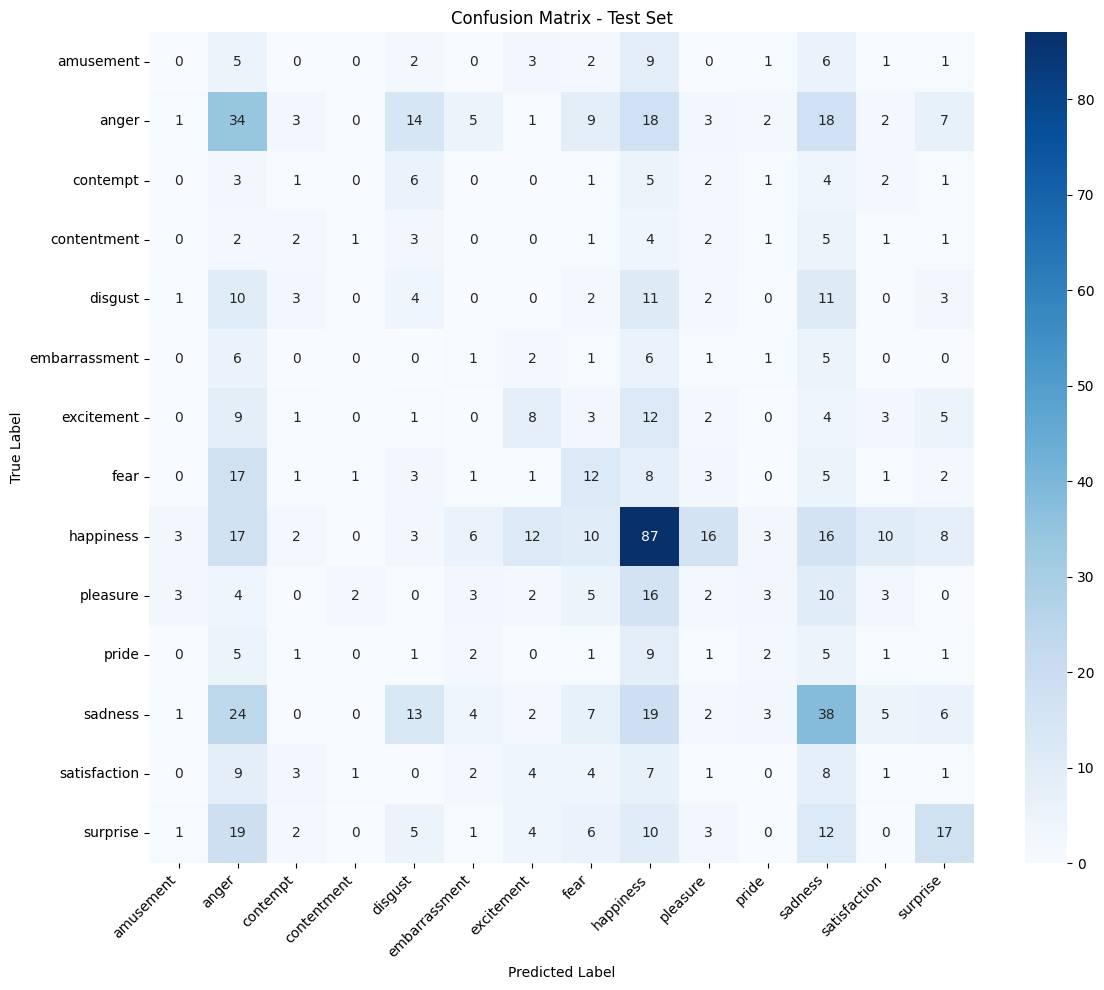


CLASSIFICATION REPORT
               precision    recall  f1-score   support

    amusement       0.00      0.00      0.00        30
        anger       0.21      0.29      0.24       117
     contempt       0.05      0.04      0.04        26
  contentment       0.20      0.04      0.07        23
      disgust       0.07      0.09      0.08        47
embarrassment       0.04      0.04      0.04        23
   excitement       0.21      0.17      0.18        48
         fear       0.19      0.22      0.20        55
    happiness       0.39      0.45      0.42       193
     pleasure       0.05      0.04      0.04        53
        pride       0.12      0.07      0.09        29
      sadness       0.26      0.31      0.28       124
 satisfaction       0.03      0.02      0.03        41
     surprise       0.32      0.21      0.26        80

     accuracy                           0.23       889
    macro avg       0.15      0.14      0.14       889
 weighted avg       0.22      0.23      

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.emotions,
            yticklabels=train_dataset.emotions)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification report
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print(f"{'='*60}")
print(classification_report(all_labels, all_preds, 
                          target_names=train_dataset.emotions,
                          zero_division=0))

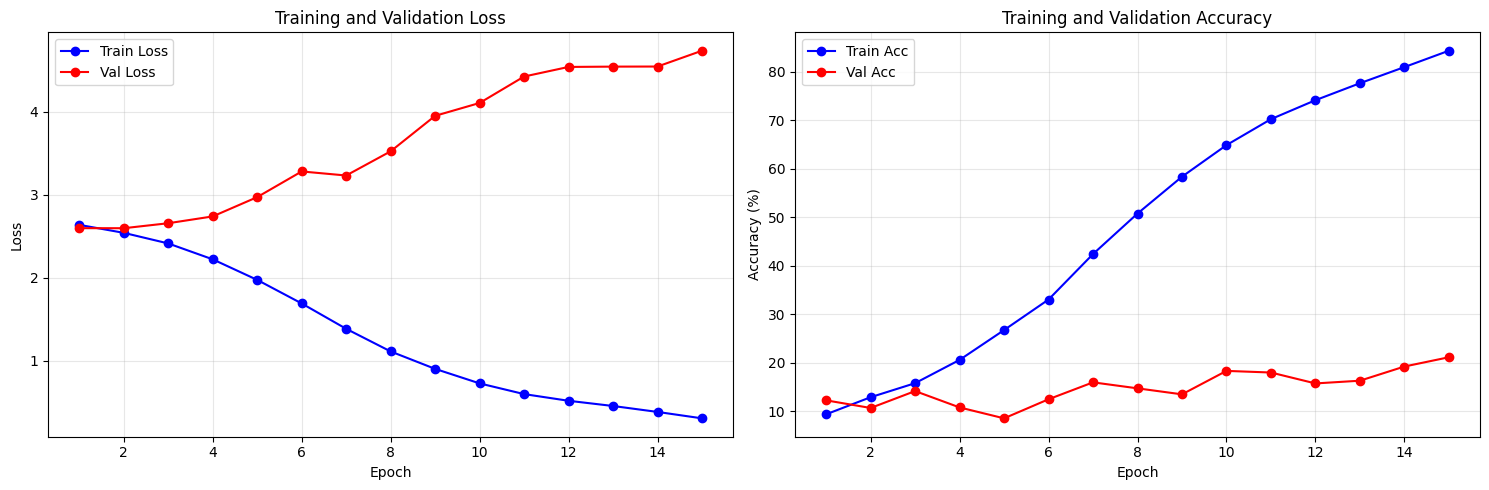

 Training curves saved as 'training_curves.png'


In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
epochs = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs, history['val_loss'], 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(epochs, history['val_acc'], 'r-o', label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Training curves saved as 'training_curves.png'")

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

class PreprocessedGIFDataset(Dataset):
    """Dataset for preprocessed single-frame GIFs"""
    
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        
        # Create emotion mapping
        self.emotions = sorted(self.data['primary_emotion'].unique())
        self.emotion2idx = {emotion: idx for idx, emotion in enumerate(self.emotions)}
        self.idx2emotion = {idx: emotion for emotion, idx in self.emotion2idx.items()}
        
        print(f" Loaded {len(self.data)} samples")
        print(f"   Emotions: {self.emotions}")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Load preprocessed frame
        frame_path = row['frame_path']
        frame = Image.open(frame_path).convert('RGB')
        
        # Get label
        emotion = row['primary_emotion']
        label = self.emotion2idx[emotion]
        
        # Apply transform
        if self.transform:
            frame = self.transform(frame)
        
        return frame, label

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = PreprocessedGIFDataset('processed_frames_single/train_processed.csv', transform=train_transform)
val_dataset = PreprocessedGIFDataset('processed_frames_single/val_processed.csv', transform=val_transform)
test_dataset = PreprocessedGIFDataset('processed_frames_single/test_processed.csv', transform=val_transform)

# Create dataloaders
BATCH_SIZE = 32
NUM_WORKERS = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\n DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# Test loading a batch
#images, labels = next(iter(train_loader))
#print(f"\n Batch test successful:")
#print(f"   Images shape: {images.shape}")  # Should be (32, 3, 224, 224)
#print(f"   Labels shape: {labels.shape}")  # Should be (32,)

# Test if data loading works
print("Testing data loading...")

import time
start = time.time()

# Try loading one batch
try:
    batch = next(iter(train_loader))
    images, labels = batch
    elapsed = time.time() - start
    
    print(f" Batch loaded successfully in {elapsed:.2f} seconds")
    print(f"   Images shape: {images.shape}")
    print(f"   Labels shape: {labels.shape}")
    print(f"   Sample labels: {labels[:5]}")
    
except Exception as e:
    print(f" Error loading batch: {e}")
    import traceback
    traceback.print_exc()

 Loaded 4145 samples
   Emotions: ['amusement', 'anger', 'contempt', 'contentment', 'disgust', 'embarrassment', 'excitement', 'fear', 'happiness', 'pleasure', 'pride', 'sadness', 'satisfaction', 'surprise']
 Loaded 889 samples
   Emotions: ['amusement', 'anger', 'contempt', 'contentment', 'disgust', 'embarrassment', 'excitement', 'fear', 'happiness', 'pleasure', 'pride', 'sadness', 'satisfaction', 'surprise']
 Loaded 889 samples
   Emotions: ['amusement', 'anger', 'contempt', 'contentment', 'disgust', 'embarrassment', 'excitement', 'fear', 'happiness', 'pleasure', 'pride', 'sadness', 'satisfaction', 'surprise']

 DataLoaders created:
   Train batches: 130
   Val batches: 28
   Test batches: 28
Testing data loading...


In [ ]:
# Create datasets
train_dataset = GIFEmotionDataset('train_split.csv', num_frames=8, transform=train_transform)
val_dataset = GIFEmotionDataset('val_split.csv', num_frames=8, transform=val_transform)
test_dataset = GIFEmotionDataset('test_split.csv', num_frames=8, transform=val_transform)

# Create dataloaders
BATCH_SIZE = 16
NUM_WORKERS = 4  # Adjust based on your CPU cores

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                         shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, 
                       shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, 
                        shuffle=False, num_workers=NUM_WORKERS)


print(f" DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Test loading a batch
print("\nTesting batch loading...")
frames_batch, labels_batch = next(iter(train_loader))
print(f"  Frames shape: {frames_batch.shape}")  # Should be (batch_size, num_frames, 3, 224, 224)
print(f"  Labels shape: {labels_batch.shape}")  # Should be (batch_size,)
print(f"  Sample labels: {labels_batch[:5]}")

Loaded 4146 samples
Emotions (14): ['amusement', 'anger', 'contempt', 'contentment', 'disgust', 'embarrassment', 'excitement', 'fear', 'happiness', 'pleasure', 'pride', 'sadness', 'satisfaction', 'surprise']
Loaded 889 samples
Emotions (14): ['amusement', 'anger', 'contempt', 'contentment', 'disgust', 'embarrassment', 'excitement', 'fear', 'happiness', 'pleasure', 'pride', 'sadness', 'satisfaction', 'surprise']
Loaded 889 samples
Emotions (14): ['amusement', 'anger', 'contempt', 'contentment', 'disgust', 'embarrassment', 'excitement', 'fear', 'happiness', 'pleasure', 'pride', 'sadness', 'satisfaction', 'surprise']
 DataLoaders created:
  Train batches: 260
  Val batches: 56
  Test batches: 56

Testing batch loading...
